<a href="https://colab.research.google.com/github/apoorv280/Machine-Learning-Projects/blob/main/CreditCard_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
# Loading the data and print first 5 rows
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Getting the size of the data
df.shape

(284807, 31)

In [ ]:
# checking Null Values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Getting the information about data-type
# and count of the data column wise
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Step 2: Data Visualization


*   Visualize Class Imbalance
*   Transaction Amount by Class
*   Transaction Count over Time
*   Correlation heatmap of Features
*   Distribution of Features by Class








In [ ]:
# Print Value counts of Class
# Legit -> 0 and Fraud -> 1
df['Class']. value_counts()
print(f'Legitimate: {df['Class'].value_counts()[0]}')
print(f'Fraudulent: {df['Class'].value_counts()[1]}')

Legitimate: 284315
Fraudulent: 492


## We can visualize the dataset

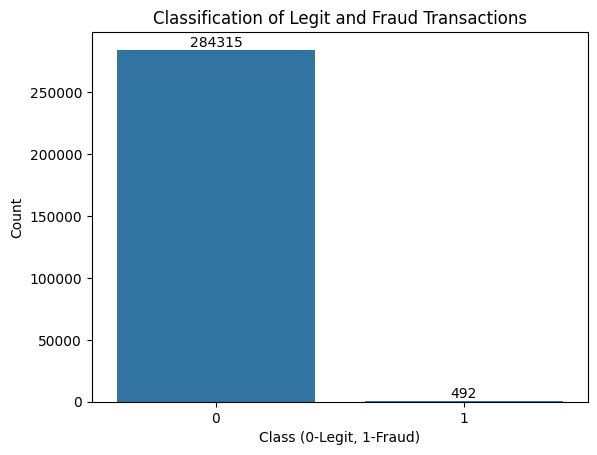

In [ ]:
plt.title('Classification of Legit and Fraud Transactions')
ax = sns.countplot(x='Class', data= df)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel("Class (0-Legit, 1-Fraud)")
plt.ylabel("Count")
plt.show()

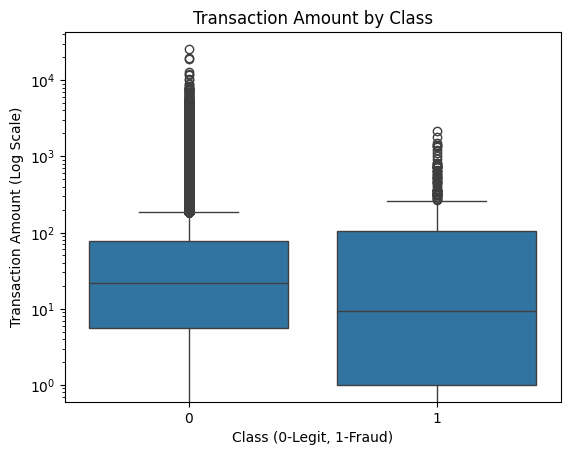

In [ ]:
plt.title('Transaction Amount by Class')
ax = sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.xlabel("Class (0-Legit, 1-Fraud)")
plt.ylabel("Transaction Amount (Log Scale)")
plt.show()

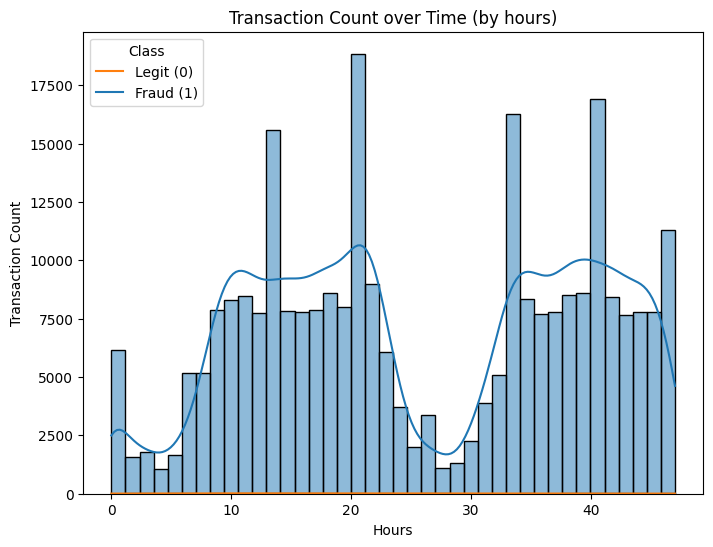

In [ ]:
df['Hours'] = df['Time'] // 3600

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Hours',hue='Class', bins=40, kde=True)
plt.title('Transaction Count over Time (by hours)')
plt.xlabel('Hours')
plt.ylabel('Transaction Count')
plt.legend(title = 'Class', labels = ['Legit (0)', 'Fraud (1)'])
plt.show()

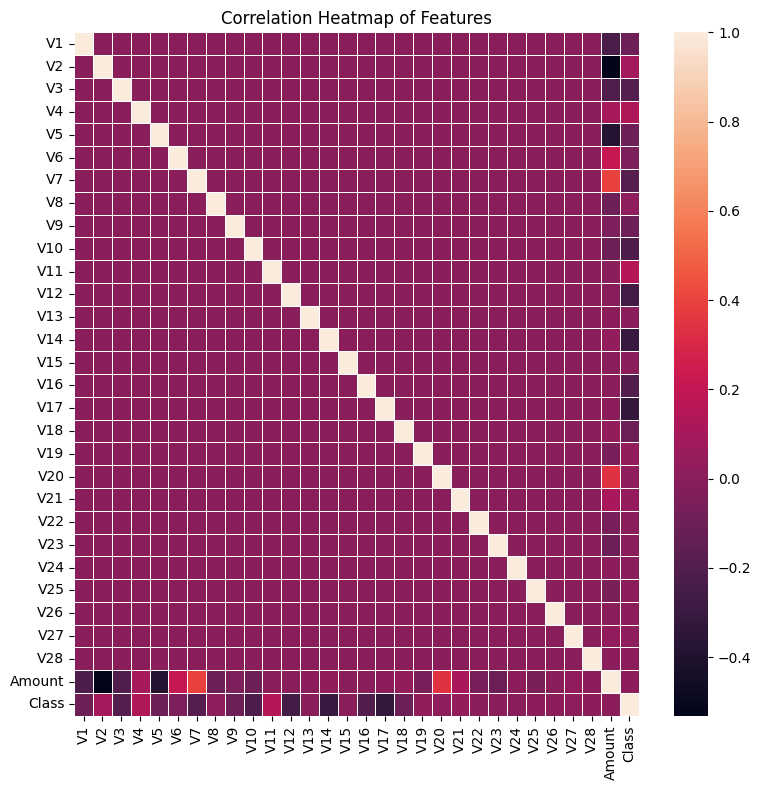

In [ ]:
corr_matrix = df.drop(columns=['Time','Hours']).corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

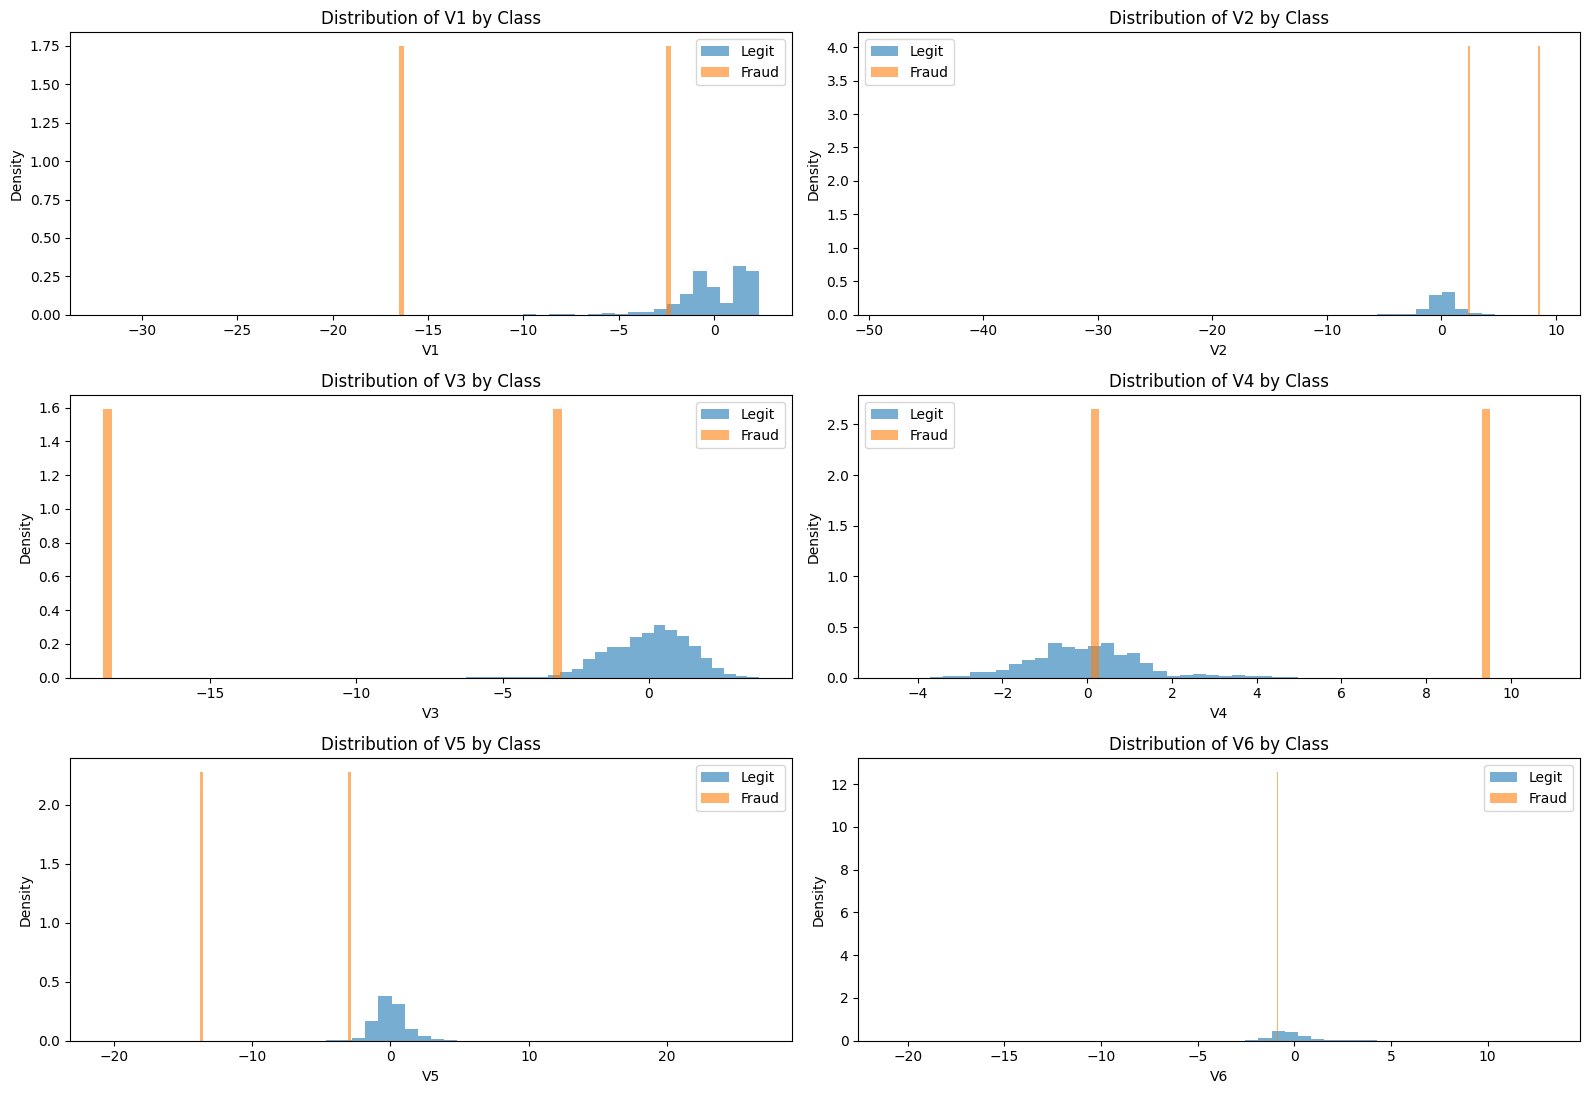

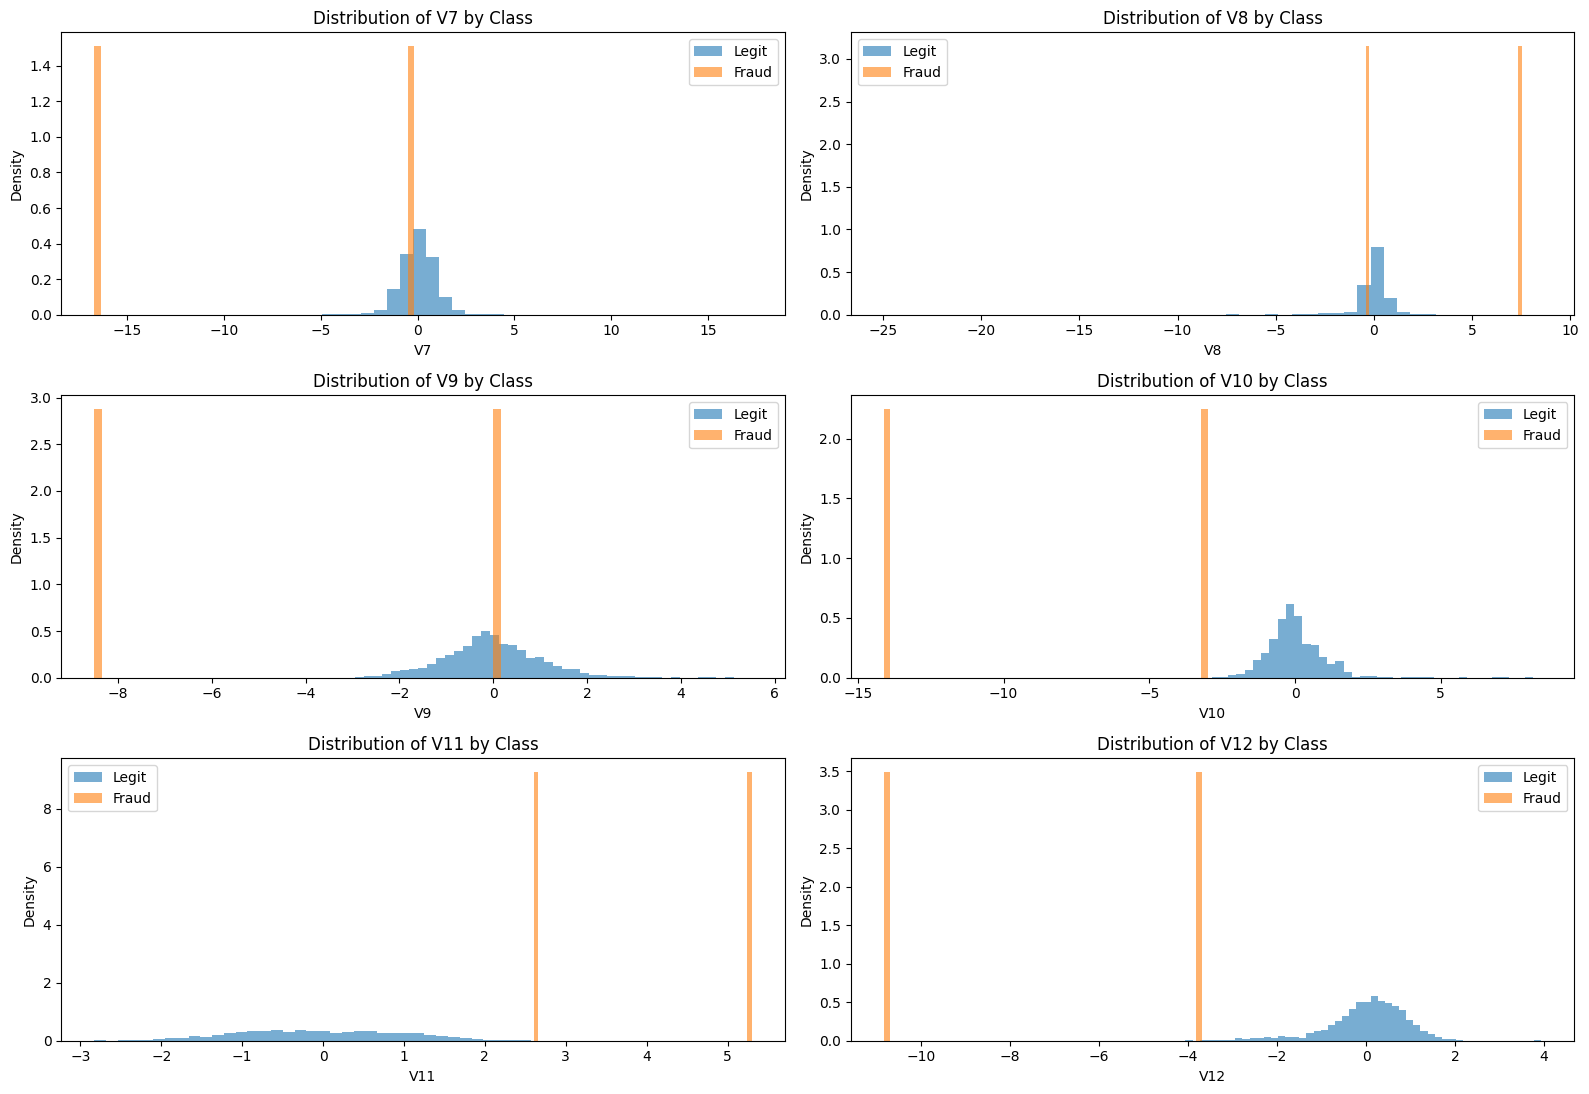

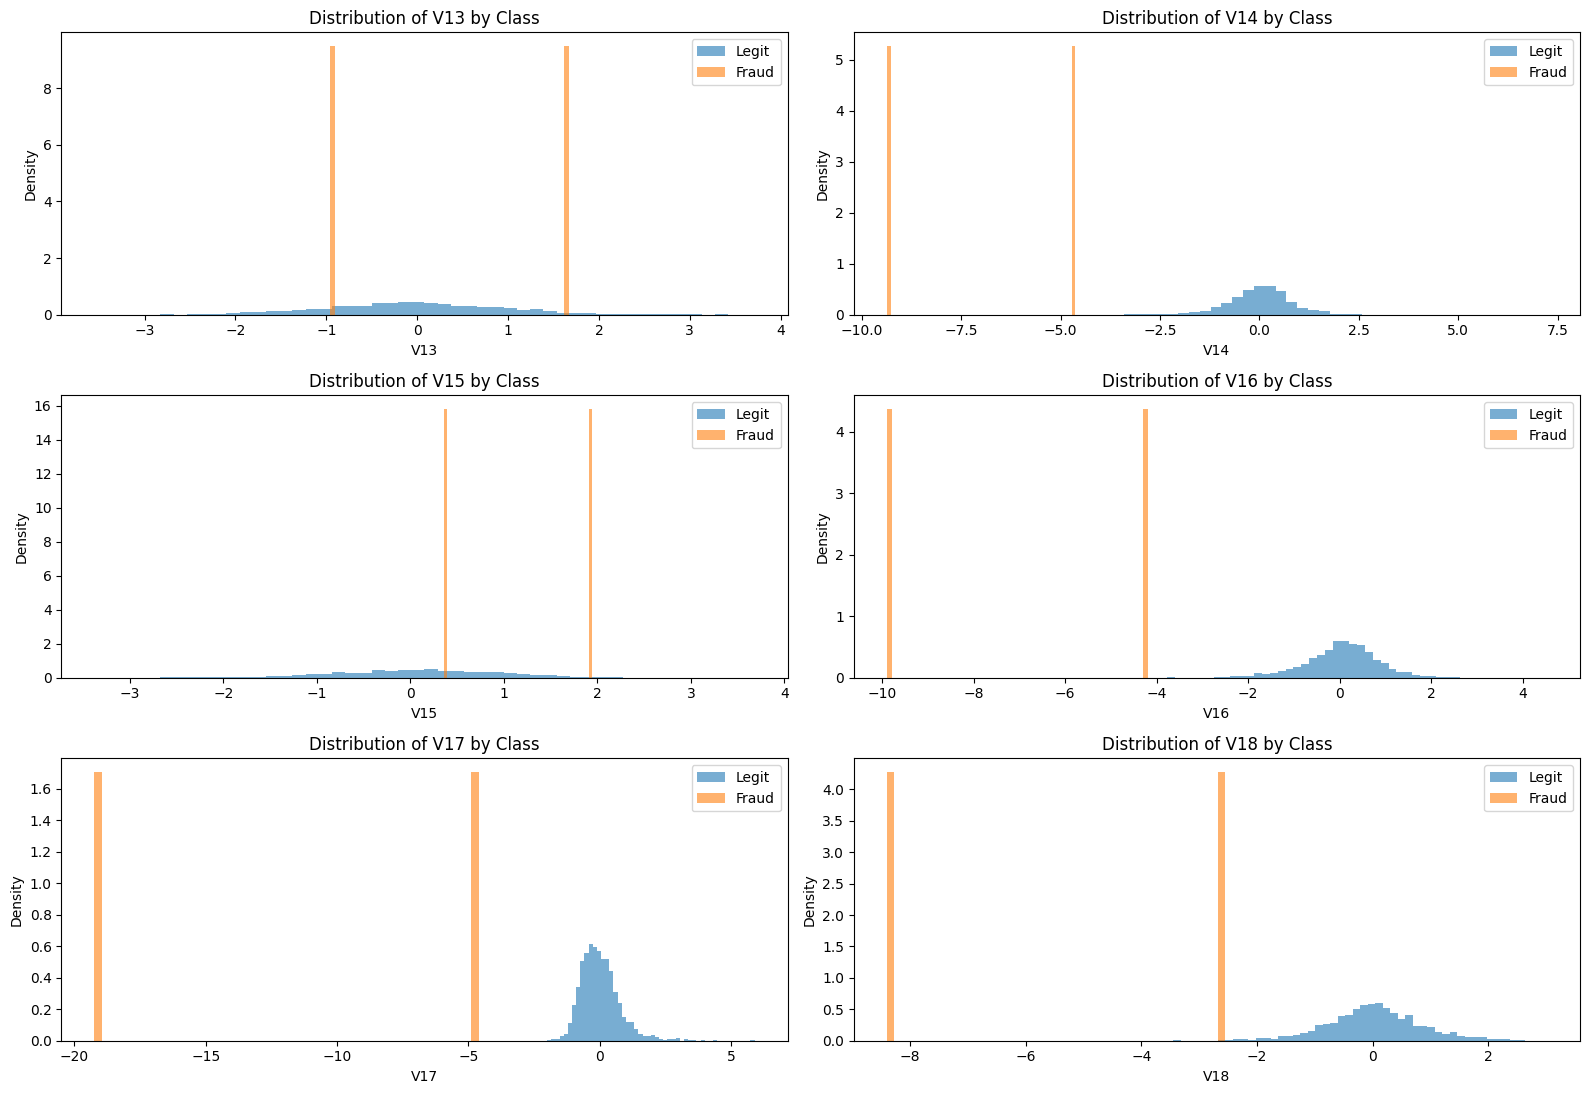

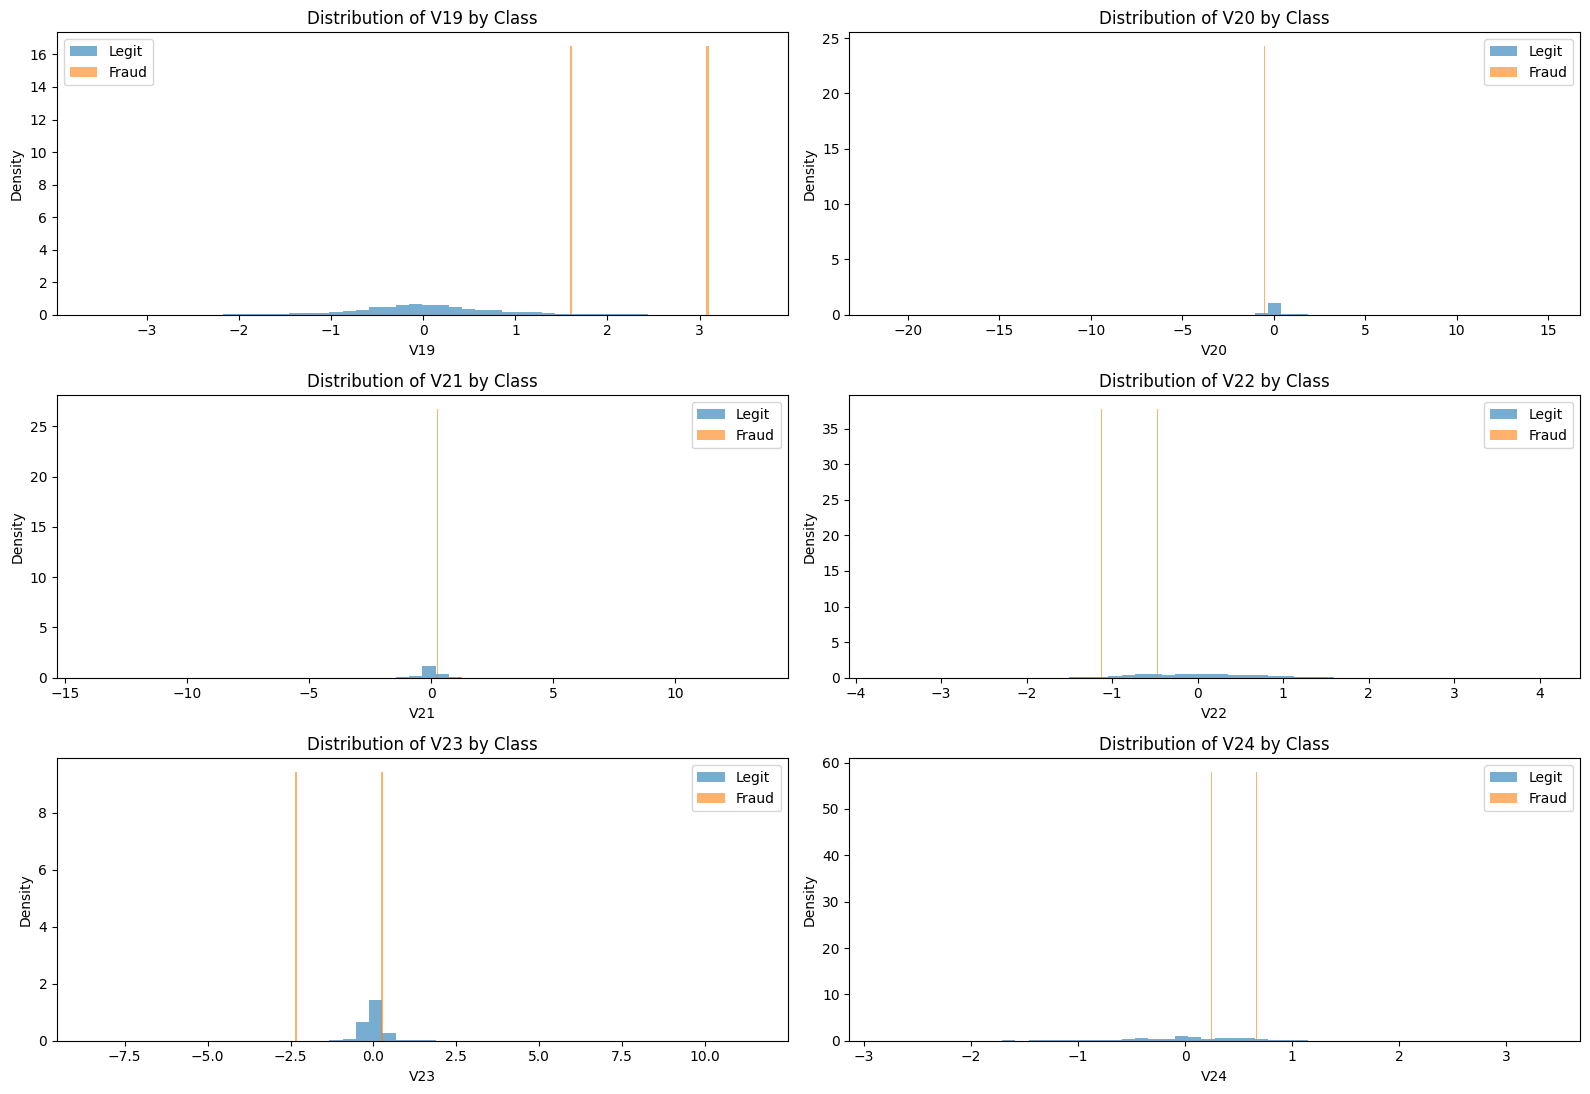

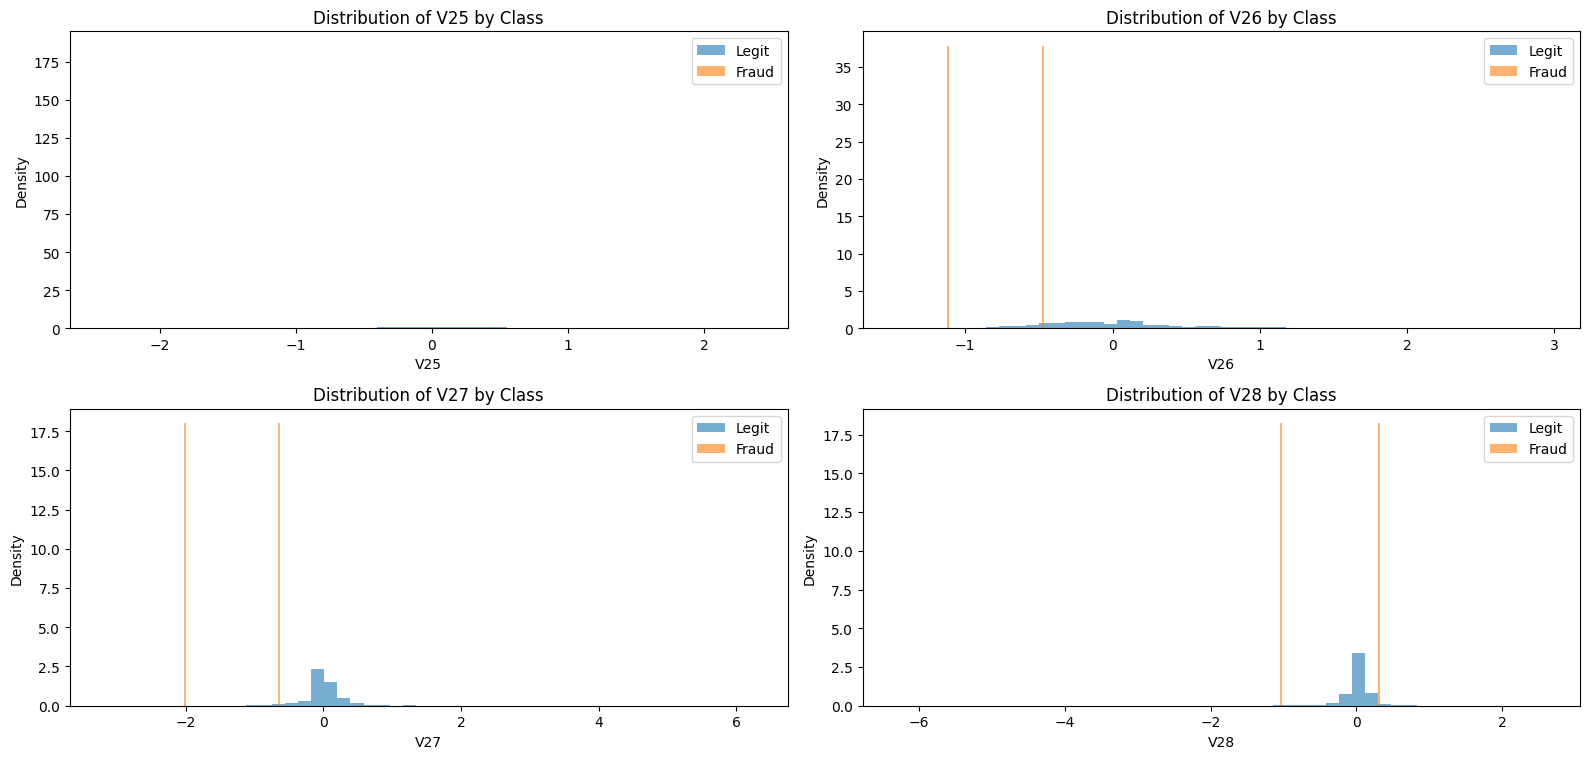

In [ ]:
# Distribution of each feature with respect to Class

columns = ['V' + str(i) for i in range(1,29)] + ['Class']
df = df.apply(pd.to_numeric, errors = 'coerce').dropna()

sample_df = df.sample(n = 3000, random_state=42)
features = ['V' + str(i) for i in range(1,29)]

chunks = [features[i:i+6] for i in range(0, len(features), 6)]

for num, chunk in enumerate(chunks, 1):
  plt.figure(figsize=(16,12))
  for i , feature in enumerate(chunk, 1):
    plt.subplot(3,2,i)
    plt.hist(sample_df[sample_df['Class'] == 0][feature],bins=50, alpha = 0.6, label = 'Legit', density=True)
    plt.hist(sample_df[sample_df['Class'] == 1][feature],bins=50, alpha = 0.6, label = 'Fraud', density=True)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()

  plt.tight_layout(rect=[0,0.03,1,0.95])
  plt.show()

In [ ]:
# train test split
X = df.drop('Class',axis=1)
y = df['Class']

In [ ]:
# split the dataset into straining and testing
# stratify=y ensures class ratio is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Initialize SMOTE( Synthetic Minority Oversampling Technique)
sm = SMOTE(random_state=42)

In [ ]:
# Apply SMOTE only on the training set to balance the classes
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [ ]:
# Display class distribution before and after applying SMOTE
print(f'Class Distribution before SMOTE: {y_train.value_counts()}')
print(f'Class Distribution after SMOTE: {y_train_resampled.value_counts()}')

Class Distribution before SMOTE: Class
0    199020
1       344
Name: count, dtype: int64
Class Distribution after SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
# Initialize and traon Logistic Regression model
# class_weight = balanced helps handle class imbalance during training

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_resampled, y_train_resampled)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# make predictions on original imbalanced test set
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# print classification report to show precision, recall and f1 score
print(f'Classification Report for Logistic Regression:\n {classification_report(y_test, y_pred_lr)}')

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     85295
           1       0.13      0.85      0.22       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.61     85443
weighted avg       1.00      0.99      0.99     85443



Confusion Matrix for Logistic Regression:


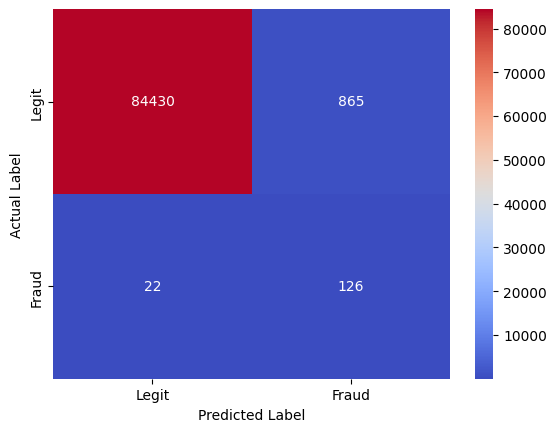

In [ ]:
# generate and visualize the confusion matrix
print('Confusion Matrix for Logistic Regression:')

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, cmap="coolwarm", fmt='d', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit','Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
print(f'ROC AUC score for Logistic regression: {roc_auc_score(y_test, y_pred_lr)}')

ROC AUC score for Logistic regression: 0.9206050384753709


## Random Forest

In [ ]:
## Initialize and train Random forest classifier
rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# make predictions on original imbalanced dataset
y_pred_rf = rf_model.predict(X_test)

# Print classification report
print(f'Classification Report for Random Forest:\n {classification_report(y_test,y_pred_rf)}')

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.80      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



Confusion Matrix for Random Forest:


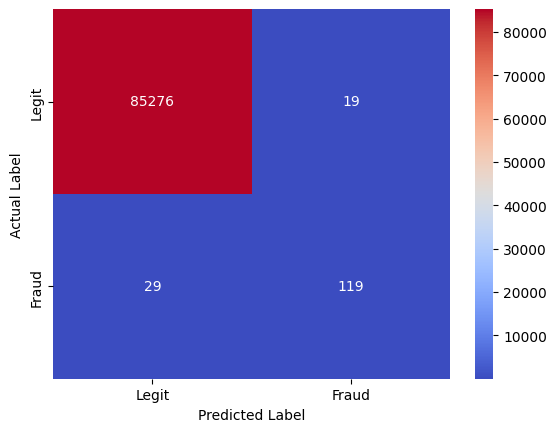

ROC-AUC score for Random Forest: 0.90191564886887


In [ ]:
# Generate and visualize confusion matrix
print('Confusion Matrix for Random Forest:')
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot = True,cmap="coolwarm", fmt='d', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# print roc_auc score
print(f'ROC-AUC score for Random Forest: {roc_auc_score(y_test,y_pred_rf)}')

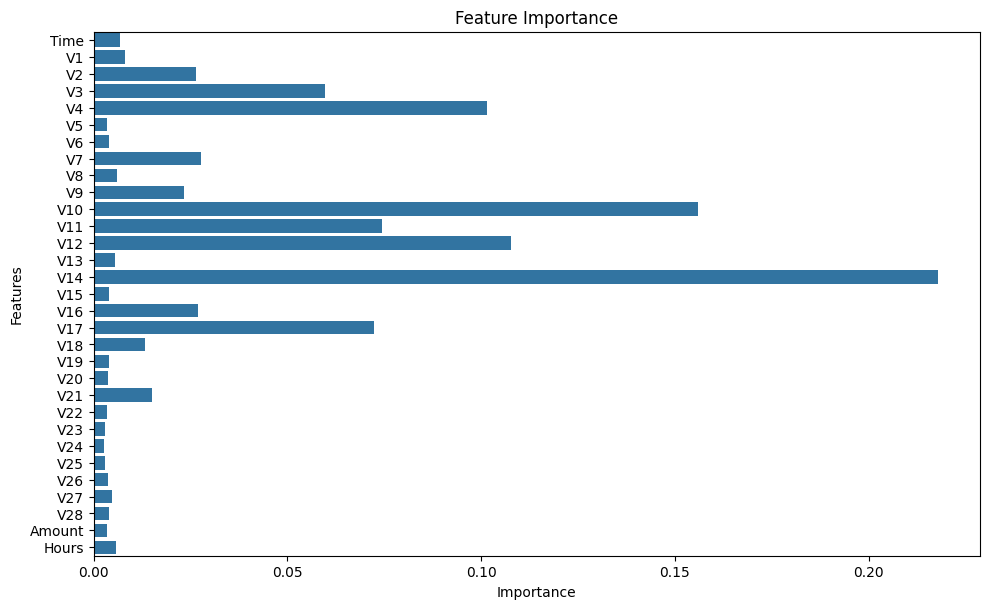

In [ ]:
importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.tight_layout()
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [ ]:
# Initialize and train XGBoost model
# scale_pos_weight=1: weight given to positive class
# use_label_encoder = False avoids deprecation warning
# eval_metrics = 'logloss': metrics used during training

xgb_model = xgb.XGBClassifier(scale_pos_weight=1, use_label_encoder=False, eval_metric = 'logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Classification Report for XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.82      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.91      0.92     85443
weighted avg       1.00      1.00      1.00     85443

Confusion matrix for XGBoost


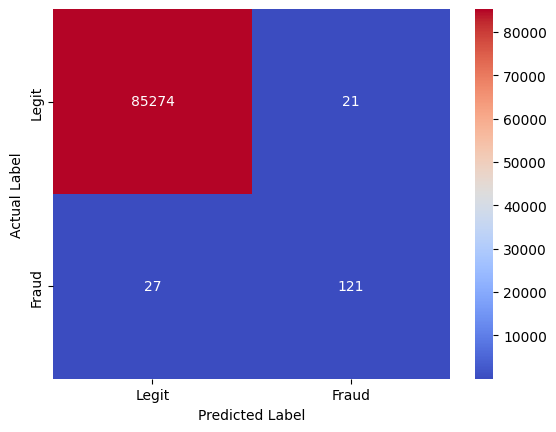

ROC AUC score for XGBoost: 0.9086606816089786


In [ ]:
# make predictions on original imbalanced dataset
y_pred_xgb = xgb_model.predict(X_test)

# Print classification report
print(f'Classification Report for XGBoost:\n {classification_report(y_test,y_pred_xgb)}')

# Generate and visualize the confusion matrix
print("Confusion matrix for XGBoost")
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True,cmap='coolwarm', fmt='d',xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Print ROC_AUC score
print(f'ROC AUC score for XGBoost: {roc_auc_score(y_test,y_pred_xgb)}')

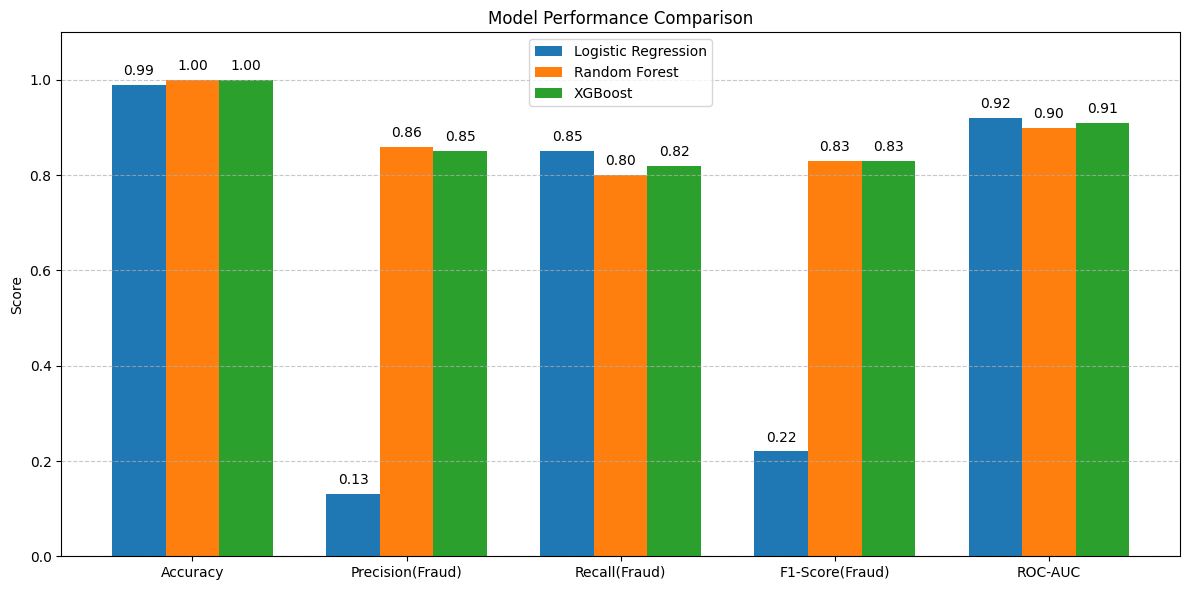

In [ ]:
# Define metrics to compare
metrics = ['Accuracy', 'Precision(Fraud)','Recall(Fraud)', 'F1-Score(Fraud)', 'ROC-AUC']

# scores of each model
logistic = [0.99, 0.13, 0.85, 0.22, 0.92]
random_forest = [1.00, 0.86, 0.80, 0.83, 0.90]
xgboost = [1.00, 0.85, 0.82, 0.83, 0.91]

# setup bar width and positions
bar_width = 0.25
x = np.arange(len(metrics))

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x-bar_width, logistic, width=bar_width, label='Logistic Regression')
bars2 = plt.bar(x, random_forest, width=bar_width, label = 'Random Forest')
bars3 = plt.bar(x + bar_width, xgboost, width=bar_width, label='XGBoost')

# annotate bar heights with exact values

for bars in [bars1, bars2, bars3]:
  for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}',
                 xy=(bar.get_x()+bar.get_width()/2,height),
                 xytext=(0,5),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=10)

# formatting
plt.xticks(x,metrics)
plt.ylim(0,1.1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# Display
plt.show()


# Final Conclusion
In this project, I tackled the problem of detecting fraudulent credit card transactions using machine learning techniques. The dataset had significant class imbalance which was handled using SMOTE(Synthetic Minority Oversampling Technique) to ensure the models to detect fraud more effectively.

### Key Findings

*   **Logistic Regression** achieved highest **ROC-AUC (0.92)**
*   List item

